In [1]:
!pip install torch

     -------------------------------------- 199.3/199.3 MB 1.0 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.3.0
    Uninstalling typing_extensions-4.3.0:
      Successfully uninstalled typing_extensions-4.3.0


In [4]:
!pip install torchvision  

     ---------------------------------------- 1.3/1.3 MB 4.8 MB/s eta 0:00:00


In [5]:
import torch as th
import numpy as np
import random

#сделаем инициализацию random seed, 
#чтобы наши эксперименты были воспроизводимы

random.seed(0)
np.random.seed(0)
th.manual_seed(0)
th.cuda.manual_seed(0)
th.backends.cudnn.deterministic=True

In [6]:
#скачивание датасета для классификации изображений
import torchvision.datasets

MNIST_train = torchvision.datasets.MNIST('./', download = True, train = True)
MNIST_test = torchvision.datasets.MNIST('./', download = True, train = False)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|███████████████████████████████████████████████████████████████████| 9912422/9912422 [00:04<00:00, 2146636.78it/s]


Extracting ./MNIST\raw\train-images-idx3-ubyte.gz to ./MNIST\raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|████████████████████████████████████████████████████████████████████████| 28881/28881 [00:00<00:00, 226191.02it/s]


Extracting ./MNIST\raw\train-labels-idx1-ubyte.gz to ./MNIST\raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|███████████████████████████████████████████████████████████████████| 1648877/1648877 [00:01<00:00, 1571907.11it/s]


Extracting ./MNIST\raw\t10k-images-idx3-ubyte.gz to ./MNIST\raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████████████████████████████████████████████████████████████████████| 4542/4542 [00:00<00:00, 757687.18it/s]


Extracting ./MNIST\raw\t10k-labels-idx1-ubyte.gz to ./MNIST\raw



In [7]:
X_train = MNIST_train.train_data
y_train = MNIST_train.train_labels
X_test = MNIST_test.test_data
y_test = MNIST_test.test_labels

C:\Users\user\anaconda3\lib\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
C:\Users\user\anaconda3\lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
C:\Users\user\anaconda3\lib\site-packages\torchvision\datasets\mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
C:\Users\user\anaconda3\lib\site-packages\torchvision\datasets\mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


In [8]:
#посмотрим какой у данных тип
X_train.dtype, y_train.dtype

(torch.uint8, torch.int64)

In [10]:
#данные имеют тип беззнаковый 8, а таргеты - целые 64 бита
#преобразуем сразу данные в веществиенный тип
X_train = X_train.float()
X_test = X_test.float()

In [11]:
#посмотрим на расзмерность датасетов
X_train.shape, X_test.shape
#это очень маленькие картинки, именно поэтому мы можем использовать
#полносвязную нейронную сеть для такой задачи, а не сверточные сети

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

In [12]:
y_train.shape, y_test.shape

(torch.Size([60000]), torch.Size([10000]))

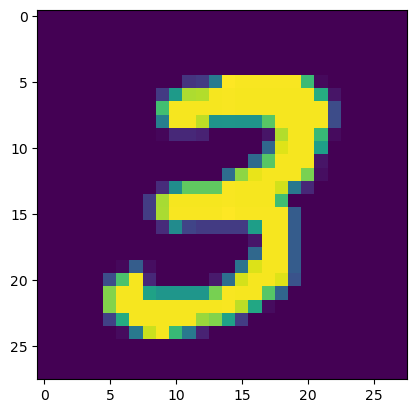

tensor(3)


In [13]:
#посмотрим на картинки
import matplotlib.pyplot as plt
plt.imshow(X_train[7, :, :])
plt.show()
print(y_train[7])

In [14]:
#у нас трезмерный тензор, мы хотим двумерный тензор, 
#чтобы первая рамерность сохранилась, то есть 60000 картинок
#вместо 28 и 28 будет 764 пикселя

X_train = X_train.reshape([-1, 28*28])
X_test = X_test.reshape([-1, 28*28])

print(X_train)


tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [17]:
#Создание сети
# на выходе у нас числа от 0 до 9
#состоит из нескольких полносвязных слоев (т.е. 2х)
class MNISTnet(th.nn.Module):
  def __init__(self, n_hidden_neurons):
    super (MNISTnet, self).__init__()
    self.fc1 = th.nn.Linear(28*28, n_hidden_neurons)# слой, на вход которому приходит 28*2 пикселя, они передаются в n_hidden_neurons(ee задаем свободно)
    self.ac1 = th.nn.Sigmoid()# сигмоидна активация для добавления нелинейности
    self.fc2 = th.nn.Linear(n_hidden_neurons, 10)# на вход 2 слоя подается n_hidden_neurons, на выходе 10 (ибо 10 классов)

  def forward(self, x):
    x = self.fc1(x)
    x = self.ac1(x)
    x = self.fc2(x)
    return x # возврат результирующего тензора (выход из 2 слоя)
  
  def predict(self,x):
    x = self.forward(x)
    return x
net = MNISTnet(100)#создадим нейронку со 100 нейронами


In [20]:
pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu117

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu117
     ---------------------------------------- 2.4/2.4 MB 5.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [21]:
''' есть ли видеокарта?'''
import torch as th
th.cuda.is_available()

False

In [22]:
'''смотрим, занята ли карта какими либо вычислениями'''
!nvidia-smi

'nvidia-smi' n'est pas reconnu en tant que commande interne
ou externe, un programme executable ou un fichier de commandes.


In [23]:
""" теперь нужно переложить вычисления на видеокарту"""

device = th.device('cuda:0' if th.cuda.is_available() else 'cpu')
net = net.to(device)
#list(net.parameters())

In [24]:
loss = th.nn.CrossEntropyLoss()#кросс-энтропия для классификации. Без софт маска быстреe идут вычисления. Софт и энтропию соединим в одну ф-ию
optimizer = th.optim.Adam(net.parameters(), lr=1.0e-3)# метод градиентного спуска - Adam. На вход - все параметры нейронной сети

In [28]:
# Определение бюджета эпох
epochs = 8  # или любое другое количество эпох, которое вы хотите использовать
batch_size = 32 # Размер батча, выберите подходящее значение для вашей задачи
test_accuracy_history = []
test_loss_history = []
#перекладываем входные данные теста на видеокарту

X_test = X_test.to(device)
y_test = y_test.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
#данные тренировочной выборки будем перекладывать на cuda по батчам
for epoch in range(epochs):
    order = np.random.permutation(len(X_train)) # перемешивания датаcета на каждой эпохe, чтобы не повторялись внутри эпохи
    for start_index in range (0, len(X_train), batch_size):
        optimizer.zero_grad()
        batch_indexes = order[start_index: start_index + batch_size]
        X_batch = X_train[batch_indexes].to(device) # выделение последовательных участков из перемешанного датасета
        y_batch = y_train[batch_indexes].to(device)
        preds = net.forward(X_batch) # прогон по слоям
        loss_value = loss(preds, y_batch)# лосс по выходам нейронки и по желаемым классам для предсказания
        loss_value.backward() # считаем градиенты
        optimizer.step()# делаем градиентный шаг
    test_preds = net.forward(X_test)# см на рост качества с каждой эпохой на всем тестовом датасет
    test_loss_history.append(loss(test_preds, y_test).item())
    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean()# доля правильных ответов. Какой наиболее вероятный класс предсказала нейронка
    test_accuracy_history.append(accuracy.item())
    # argmax выдаст номер нейрона одного из 10 и сравниваем с у-тестом. Если совпало, то отлично. Считаем среднее кол-во угадываний
    print(accuracy)

tensor(0.8941)
tensor(0.9089)
tensor(0.9112)
tensor(0.9159)
tensor(0.9115)
tensor(0.9219)
tensor(0.9137)
tensor(0.9182)


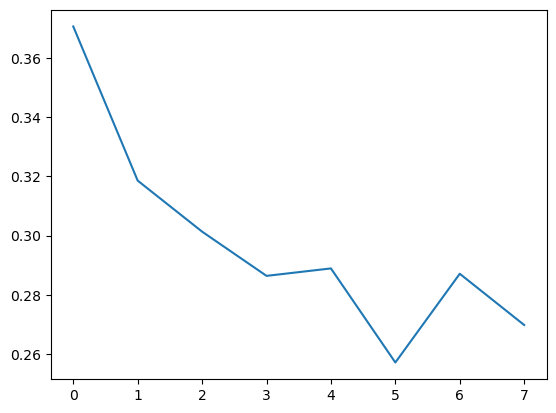

In [29]:
import matplotlib.pyplot as plt
#plt.plot(test_accuracy_history)
plt.plot(test_loss_history);

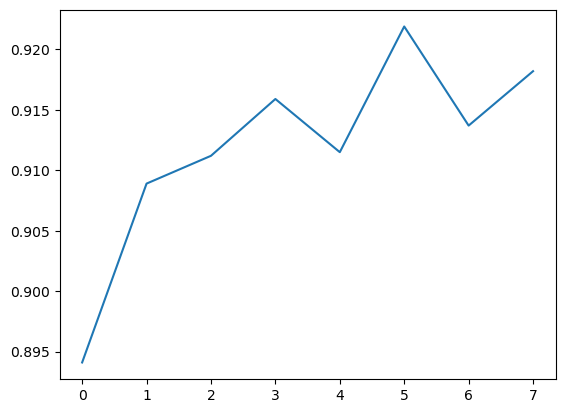

In [30]:
import matplotlib.pyplot as plt
plt.plot(test_accuracy_history)
#plt.plot(test_loss_history);